In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,roc_curve

In [21]:
from numpy.random.mtrand import random
np.random.seed(42)
n = 300
data = pd.DataFrame({
    "age":np.random.randint(18, 60, n),
    "salary":np.random.randint(20000, 100000, n),
    "balance":np.random.randint(0, 20000, n),
})
data["churn"]=(
    (data["balance"]>10000).astype(int)
).astype(int)
data.head()

,age,salary,balance,churn
0,56,59790,19760,1
1,46,25600,5645,0
2,32,60764,19870,1
3,25,94543,19968,1
4,38,65714,9588,0


In [22]:
print(data.shape)
print(data.info())
print(data.describe())
print(data['churn'].value_counts())

(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age        salary       balance       churn
count  300.000000    300.000000    300.000000  300.000000
mean    38.990000  59709.816667  10215.553333    0.506667
std     12.408187  22810.772819   5618.131661    0.500791
min     18.000000  20301.000000      9.000000    0.000000
25%     28.000000  40126.500000   5639.250000    0.000000
50%     40.000000  59189.500000  10088.000000    1.000000
75%     50.000000  79116.500000  14654.750000    1.000000
max     59.000000  99634.000000  19968.000000    1.000000
churn
1    152
0    148
Name: count, dtype: int64


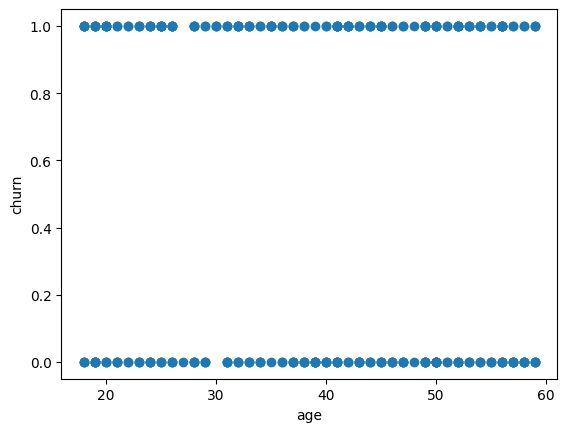

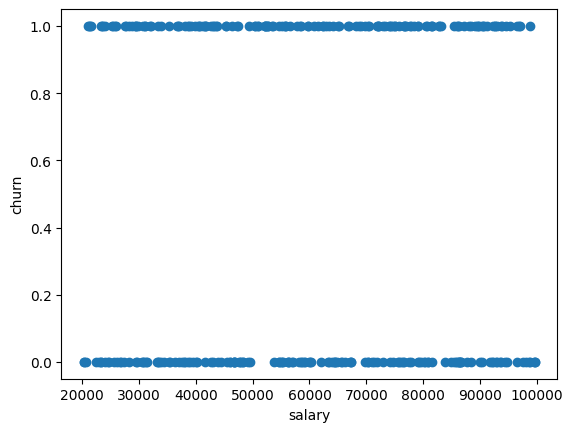

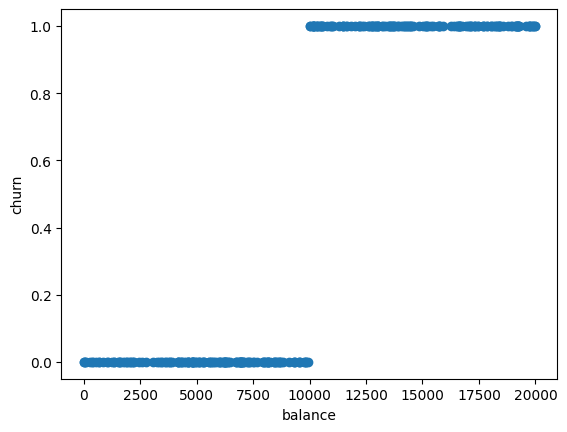

In [23]:
features = ["age", "salary", "balance"]

for col in features:
  plt.figure()
  plt.scatter(data[col], data["churn"])
  plt.xlabel(col)
  plt.ylabel("churn")
  plt.show()

In [24]:
x = data[["age", "salary", "balance"]]
y = data["churn"]

In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
    )

In [26]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [27]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [28]:
print(model.coef_)
print(model.intercept_)

[[-0.00496877 -0.00081441  0.06414635]]
[-578.66379212]


In [30]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_prob))

Accuracy: 0.9666666666666667
Confusion Matrix:
 [[26  1]
 [ 1 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        27
           1       0.97      0.97      0.97        33

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60

ROC AUC: 0.9977553310886644


In [32]:
coef_df = pd.DataFrame({
    "feature":x.columns,
    "coefficient":model.coef_[0]
})
print(coef_df)

   feature  coefficient
0      age    -0.004969
1   salary    -0.000814
2  balance     0.064146


In [34]:
now_data = pd.DataFrame({
    "age":[35],
    "salary":[90000],
    "balance":[100000]
})
print("churn prediction:",model.predict(now_data)[0])
print("Probability:",model.predict_proba(now_data)[0][1])

churn prediction: 1
Probability: 1.0
